<a href="https://colab.research.google.com/github/Eirfand1/sentiment_analysis_arknek/blob/main/Sentiment_Analysis_Arknek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sentiment Analysis review game Arknights (Google Play Store)**

Proyek ini melakukan analisis sentimen terhadap ulasan pengguna aplikasi game **Arknights** di Google Play Store. Arknights adalah game mobile strategy RPG yang dikembangkan oleh Hypergryph dan didistribusikan secara global oleh Yostar.

Saya akan mengklasifikasikan ulasan pengguna ke dalam tiga kelas sentimen: **Positif**, **Netral**, dan **Negatif**.

**Tiga skema pelatihan yang akan diuji:**
- Pelatihan RNN, 70/30
- Pelatihan GRU 80/20
- Pelatihan LSTM 80/20

# Import Libary

In [206]:
!pip install google-play-scraper

In [207]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

In [208]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks
from nltk.stem import PorterStemmer  # Stemming kata
from nltk.stem import WordNetLemmatizer  # Lemmatisasi kata
from nltk.sentiment import SentimentIntensityAnalyzer
# !pip install sastrawi
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
# from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks


In [209]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

# Scrapping Dataset

In [210]:
from google_play_scraper import app, reviews_all, Sort

scrapreview = reviews_all(
    'com.YoStarEN.Arknights',
    lang='en',
    country='us',
    sort=Sort.MOST_RELEVANT,
    count=100000
)

In [211]:
# Menyimpan ke bentuk CSV
import csv

with open('ulasan_arknights.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Review'])
    for review in scrapreview:
        writer.writerow([review['content']])

# Loading Dataset

In [212]:
app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('ulasan_arknights.csv', index=False)

In [213]:
# Membuat DataFrame
app_reviews_df = pd.DataFrame(scrapreview)

jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [214]:
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,4533db64-cb99-4501-89c0-3ed34ba30938,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"One of the few good mobile games in the 2020s, and one of the best tower defenses out there- and still has constant updates. Been playing for about 2 1/2 years with only one complaint: Auto-redeploy not always being consistent. However, I can look past it with how many characters, modes, mechanics and lore/story the game has. It'll take years to run out of things to do. Warning though, early-game you will miss out on a lot of things due to not being strong enough or having enough resources saved",5,566,28.4.01,2025-06-02 19:39:43,None,NaT,28.4.01
1,ccb34593-f129-415a-bc92-f6b0bb6674d0,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"I've been playing this game for 5 years, and I can easily say it's one of my all time favorites. Few games, or even films, tackle the subjects and themes Arknights does with this level of thoughtfulness and maturity. Every event is compelling, the cast is varied and complex, and the story and worldbuilding stand a cut above any of its contemporaries. It deserves all the support and recognition it can get. If you like political Sci Fi/fantasy and visual novels, I can't recommend it enough.",5,137,32.6.21,2026-02-10 01:19:56,None,NaT,32.6.21
2,00b39f20-6598-49b4-813b-f3bc14dd6312,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Been playing this game for 6 years now and don't regret any second of playtime. Even if you aren't the best at tower defense, there's a lot to love in this game and a dedicated fan base that makes helpful guides to get you through each stage. incredible story in both main plot and events and the characters are fun and feel fresh despite there being so many.",5,3,32.6.21,2026-02-11 04:38:32,None,NaT,32.6.21
3,8214b289-5a69-49f3-8c3b-8a8a66ee3b55,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"One of my favorite games! most people might not like the tower defense aspect of this game, but it's very engaging! Each side story seems to have a different mechanic in it, so you can look for something new each event. these mechanics go well the story, Which is really amazing. You don't need the most OP characters of the highest ranks to play, either. There are plenty of characters who are lower ranks who are amazing. Characters are also very amazingly designed. Please give this game a try!!!",5,32,32.6.21,2025-12-11 16:05:24,None,NaT,32.6.21
4,c2f5983b-af13-45f7-82f2-31a0e20cc48b,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Been playing two years solid. Likable characters, compelling story, involved gameplay, resource management, generous rewards, and a store that's not in your face, just available if you want it. Max characters are possible without ever spending a dime. I payed monthly for over a year, but it doesn't hurt other players or leave them behind, but supports them instead even without the need to friend players. Any one of these would make this a good mobile game, but it does them all better than others",5,82,31.5.80,2025-10-15 03:38:56,None,NaT,31.5.80


In [215]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31312 entries, 0 to 31311
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              31312 non-null  object        
 1   userName              31312 non-null  object        
 2   userImage             31312 non-null  object        
 3   content               31312 non-null  object        
 4   score                 31312 non-null  int64         
 5   thumbsUpCount         31312 non-null  int64         
 6   reviewCreatedVersion  23999 non-null  object        
 7   at                    31312 non-null  datetime64[ns]
 8   replyContent          4699 non-null   object        
 9   repliedAt             4699 non-null   datetime64[ns]
 10  appVersion            23999 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 2.6+ MB


In [216]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna(subset=['content', 'score'])

In [217]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31312 entries, 0 to 31311
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              31312 non-null  object        
 1   userName              31312 non-null  object        
 2   userImage             31312 non-null  object        
 3   content               31312 non-null  object        
 4   score                 31312 non-null  int64         
 5   thumbsUpCount         31312 non-null  int64         
 6   reviewCreatedVersion  23999 non-null  object        
 7   at                    31312 non-null  datetime64[ns]
 8   replyContent          4699 non-null   object        
 9   repliedAt             4699 non-null   datetime64[ns]
 10  appVersion            23999 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 2.6+ MB


In [218]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

# Preprocessing

In [219]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'\d+', '', text)

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()

    return text

def casefoldingText(text):
    return text.lower()

def tokenizingText(text):
    return word_tokenize(text)

def filteringText(tokens):
    filtered = []

    for word in tokens:
        if word not in stop_words:
            filtered.append(word)

    return filtered

def stemmingText(tokens):
    stemmed = []

    for word in tokens:
        stemmed.append(stemmer.stem(word))

    return stemmed

def toSentence(tokens):
    return " ".join(tokens)

In [220]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,4533db64-cb99-4501-89c0-3ed34ba30938,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"One of the few good mobile games in the 2020s, and one of the best tower defenses out there- and still has constant updates. Been playing for about 2 1/2 years with only one complaint: Auto-redeploy not always being consistent. However, I can look past it with how many characters, modes, mechanics and lore/story the game has. It'll take years to run out of things to do. Warning though, early-game you will miss out on a lot of things due to not being strong enough or having enough resources saved",5,566,28.4.01,2025-06-02 19:39:43,None,NaT,28.4.01
1,ccb34593-f129-415a-bc92-f6b0bb6674d0,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"I've been playing this game for 5 years, and I can easily say it's one of my all time favorites. Few games, or even films, tackle the subjects and themes Arknights does with this level of thoughtfulness and maturity. Every event is compelling, the cast is varied and complex, and the story and worldbuilding stand a cut above any of its contemporaries. It deserves all the support and recognition it can get. If you like political Sci Fi/fantasy and visual novels, I can't recommend it enough.",5,137,32.6.21,2026-02-10 01:19:56,None,NaT,32.6.21
2,00b39f20-6598-49b4-813b-f3bc14dd6312,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Been playing this game for 6 years now and don't regret any second of playtime. Even if you aren't the best at tower defense, there's a lot to love in this game and a dedicated fan base that makes helpful guides to get you through each stage. incredible story in both main plot and events and the characters are fun and feel fresh despite there being so many.",5,3,32.6.21,2026-02-11 04:38:32,None,NaT,32.6.21
3,8214b289-5a69-49f3-8c3b-8a8a66ee3b55,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"One of my favorite games! most people might not like the tower defense aspect of this game, but it's very engaging! Each side story seems to have a different mechanic in it, so you can look for something new each event. these mechanics go well the story, Which is really amazing. You don't need the most OP characters of the highest ranks to play, either. There are plenty of characters who are lower ranks who are amazing. Characters are also very amazingly designed. Please give this game a try!!!",5,32,32.6.21,2025-12-11 16:05:24,None,NaT,32.6.21
4,c2f5983b-af13-45f7-82f2-31a0e20cc48b,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Been playing two years solid. Likable characters, compelling story, involved gameplay, resource management, generous rewards, and a store that's not in your face, just available if you want it. Max characters are possible without ever spending a dime. I payed monthly for over a year, but it doesn't hurt other players or leave them behind, but supports them instead even without the need to friend players. Any one of these would make this a good mobile game, but it does them all better than others",5,82,31.5.80,2025-10-15 03:38:56,None,NaT,31.5.80
...,...,...,...,...,...,...,...,...,...,...,...
31307,7bf0e598-58ab-4854-bb9a-7250936135a8,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,: ),5,0,None,2020-02-21 21:58:19,None,NaT,None
31308,4081232e-a3ab-42bc-ac88-c64c557f2af5,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApR

In [221]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_casefoldingText'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [222]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,text_akhir
0,4533db64-cb99-4501-89c0-3ed34ba30938,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"One of the few good mobile games in the 2020s, and one of the best tower defenses out there- and still has constant updates. Been playing for about 2 1/2 years with only one complaint: Auto-redeploy not always being consistent. However, I can look past it with how many characters, modes, mechanics and lore/story the game has. It'll take years to run out of things to do. Warning though, early-game you will miss out on a lot of things due to not being strong enough or having enough resources saved",5,566,28.4.01,2025-06-02 19:39:43,None,NaT,28.4.01,One of the few good mobile games in the s and one of the best tower defenses out there and still has constant updates Been playing for about years with only one complaint Autoredeploy not always being consistent However I can look past it with how many characters modes mechanics and lorestory the game has Itll take years to run out of things to do Warning though earlygame you will miss out on a lot of things due to not being strong enough or having enough resources saved,one of the few good mobile games in the s and one of the best tower defenses out there and still has constant updates been playing for about years with only one complaint autoredeploy not always being consistent however i can look past it with how many characters modes mechanics and lorestory the game has itll take years to run out of things to do warning though earlygame you will miss out on a lot of things due to not being strong enough or having enough resources saved,"[one, of, the, few, good, mobile, games, in, the, s, and, one, of, the, best, tower, defenses, out, there, and, still, has, constant, updates, been, playing, for, about, years, with, only, one, complaint, autoredeploy, not, always, being, consistent, however, i, can, look, past, it, with, how, many, characters, modes, mechanics, and, lorestory, the, game, has, itll, take, years, to, run, out, of, things, to, do, warning, though, earlygame, you, will, miss, out, on, a, lot, of, things, due, to, not, being, strong, enough, or, having, enough, resources, saved]","[one, good, mobile, games, one, best, tower, defenses, still, constant, updates, playing, years, one, complaint, autoredeploy, always, consistent, however, look, past, many, characters, modes, mechanics, lorestory, game, itll, take, years, run, things, warning, though, earlygame, miss, lot, things, due, strong, enough, enough, resources, saved]",one good mobile games one best tower defenses still constant updates playing years one complaint autoredeploy always consistent however look past many characters modes mechanics lorestory game itll take years run things warning though earlygame miss lot things due strong enough enough resources saved
1,ccb34593-f129-415a-bc92-f6b0bb6674d0,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"I've been playing this game for 5 years, and I can easily say it's one of my all time favorites. Few games, or even films, tackle the subjects and themes Arknights does with this level of thoughtfulness and maturity. Every event is compelling, the cast is varied and complex, and the story and worldbuilding stand a cut above any of its contemporaries. It deserves all the support and recognition it can get. If you like political Sci Fi/fantasy and visual novels, I can't recommend it enough.",5,137,32.6.21,2026-02-10 01:19:56,None,NaT,32.6.21,Ive been playing this game for years and I can easily say its one of my all time favorites Few games or even films tackle the subjects and themes Arknights does with this level of thoughtfu

# Pelabelan

In [223]:
sia = SentimentIntensityAnalyzer()
def sentiment_vader(text):

    score = sia.polarity_scores(text)['compound']
    if score > 0.05:
        polarity = 'positive'
    elif score < -0.05:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [224]:
results = clean_df['text_akhir'].apply(sentiment_vader)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    23341
neutral      4761
negative     3210
Name: count, dtype: int64


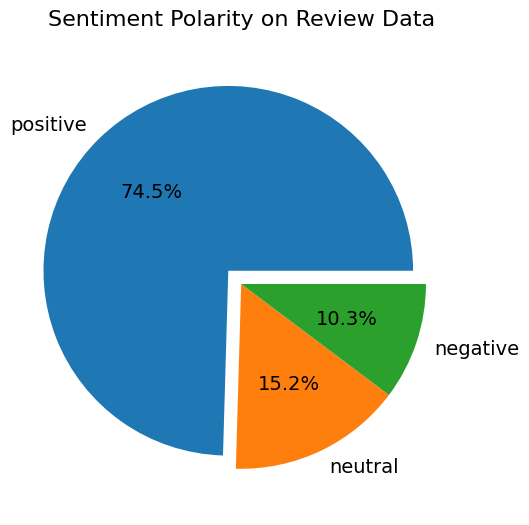

In [225]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

sizes = [count for count in clean_df['polarity'].value_counts()]

labels = list(clean_df['polarity'].value_counts().index)

explode = (0.1, 0, 0)

ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})

ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

plt.show()

In [226]:
# Positive
pd.set_option('display.max_colwidth', 3000)

positive_tweets = clean_df[clean_df['polarity'] == 'positive']

positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False)

positive_tweets = positive_tweets.reset_index(drop=True)

positive_tweets.index += 1

In [227]:
# Neutral
pd.set_option('display.max_colwidth', 3000)

neutral_tweets = clean_df[clean_df['polarity'] == 'neutral']

neutral_tweets = neutral_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

neutral_tweets = neutral_tweets.sort_values(by='polarity_score', ascending=False)

neutral_tweets = neutral_tweets.reset_index(drop=True)

neutral_tweets.index += 1

In [228]:
# Negative
pd.set_option('display.max_colwidth', 3000)

negative_tweets = clean_df[clean_df['polarity'] == 'negative']

negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=False)

negative_tweets = negative_tweets.reset_index(drop=True)

negative_tweets.index += 1

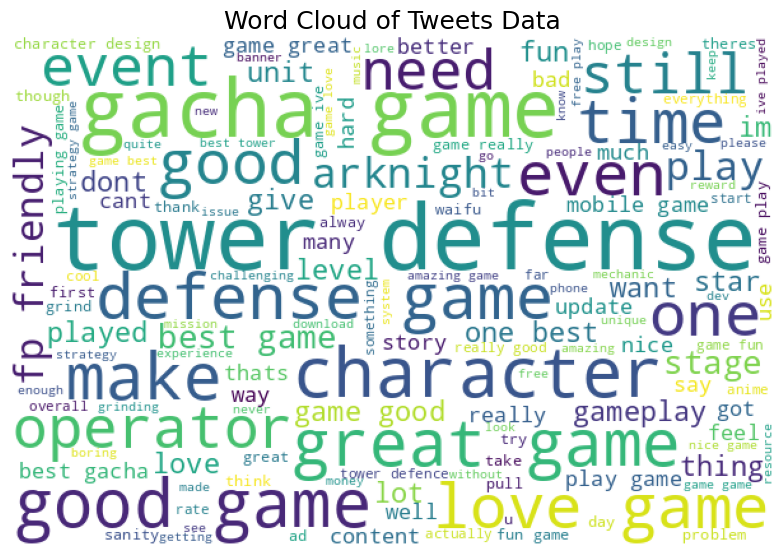

In [229]:
list_words = ''

list_words = ' '.join(
    word
    for tweet in clean_df['text_stopword']
    for word in tweet
)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Word Cloud of Tweets Data', fontsize=18)

ax.grid(False)

ax.imshow((wordcloud))

fig.tight_layout(pad=0)

ax.axis('off')

plt.show()

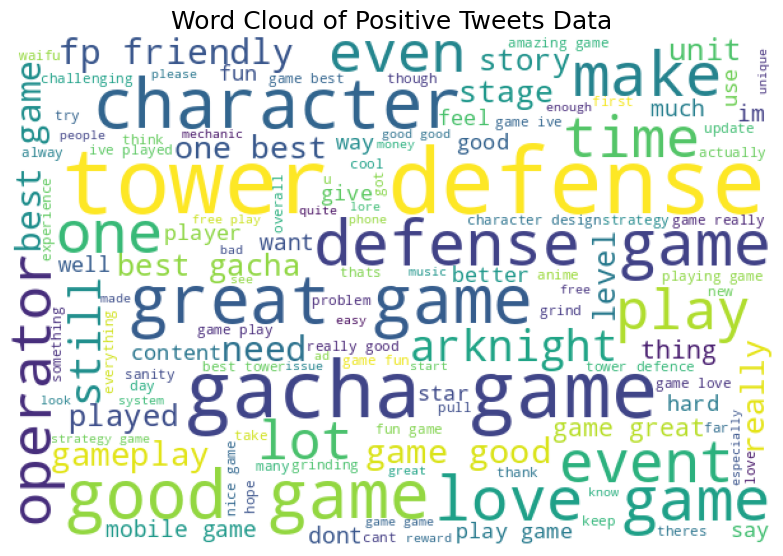

In [230]:
# list_words Positive
list_words = ''

list_words = ' '.join(
    word
    for tweet in positive_tweets['text_stopword']
    for word in tweet
)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)

ax.grid(False)

ax.imshow((wordcloud))

fig.tight_layout(pad=0)

ax.axis('off')

plt.show()

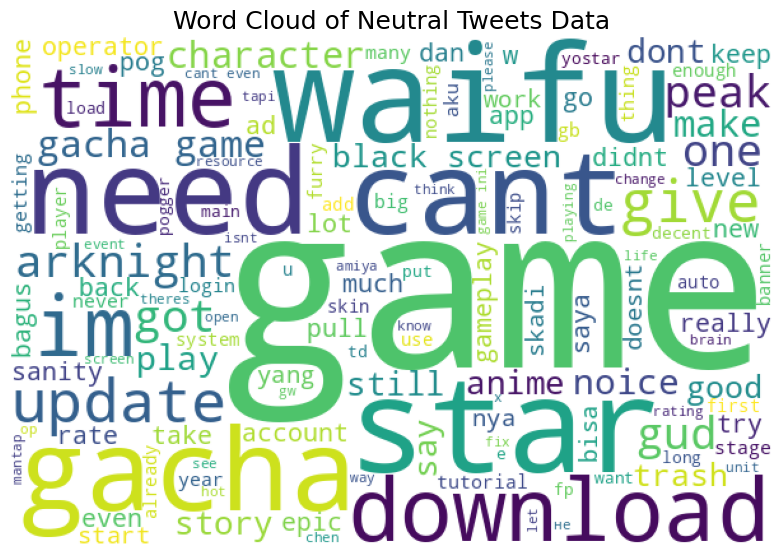

In [231]:
# list_words Neutral
list_words = ''

list_words = ' '.join(
    word
    for tweet in neutral_tweets['text_stopword']
    for word in tweet
)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Word Cloud of Neutral Tweets Data', fontsize=18)

ax.grid(False)

ax.imshow((wordcloud))

fig.tight_layout(pad=0)

ax.axis('off')

plt.show()

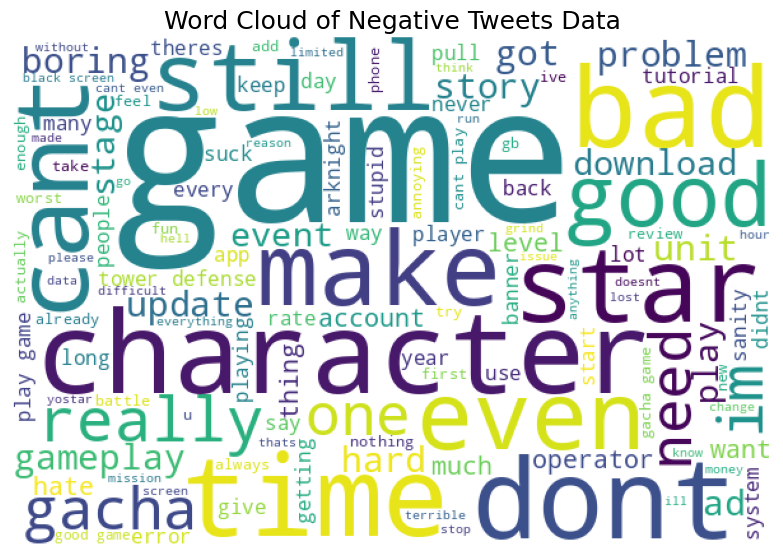

In [232]:
# list_words Negative
list_words = ''

list_words = ' '.join(
    word
    for tweet in negative_tweets['text_stopword']
    for word in tweet
)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

ax.grid(False)

ax.imshow((wordcloud))

fig.tight_layout(pad=0)

ax.axis('off')

plt.show()

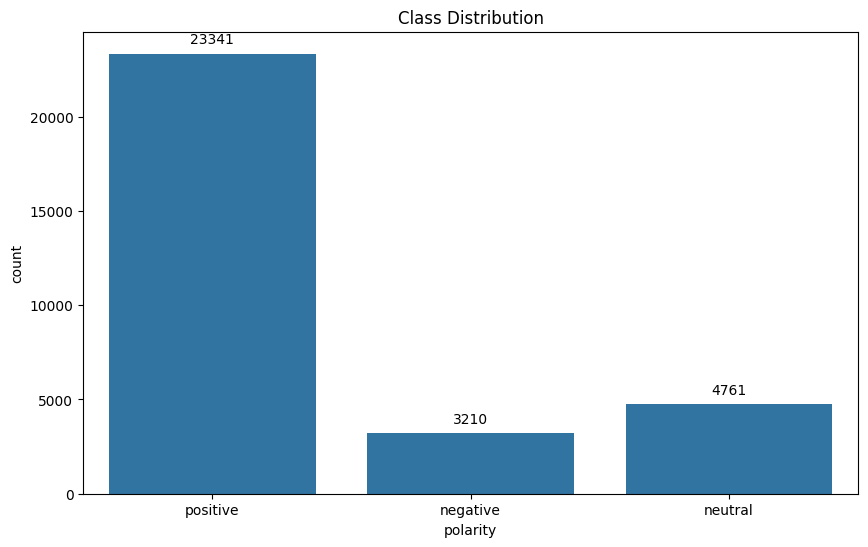

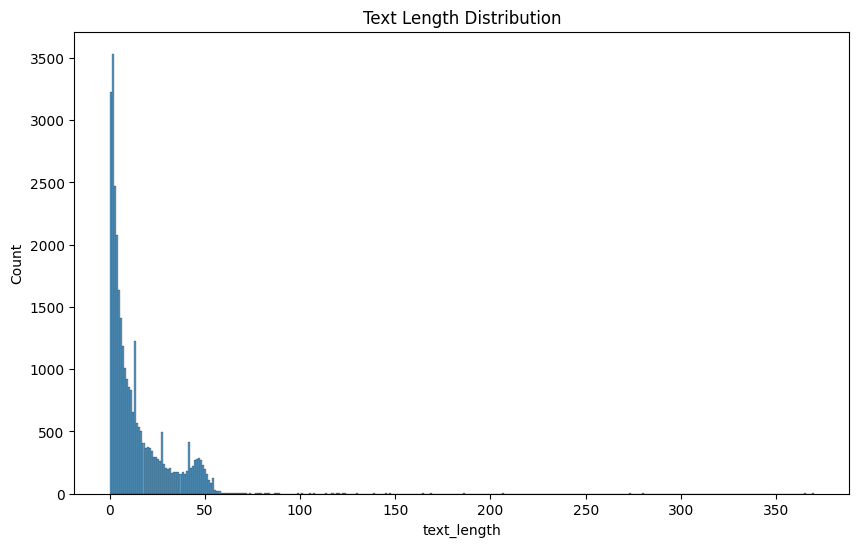

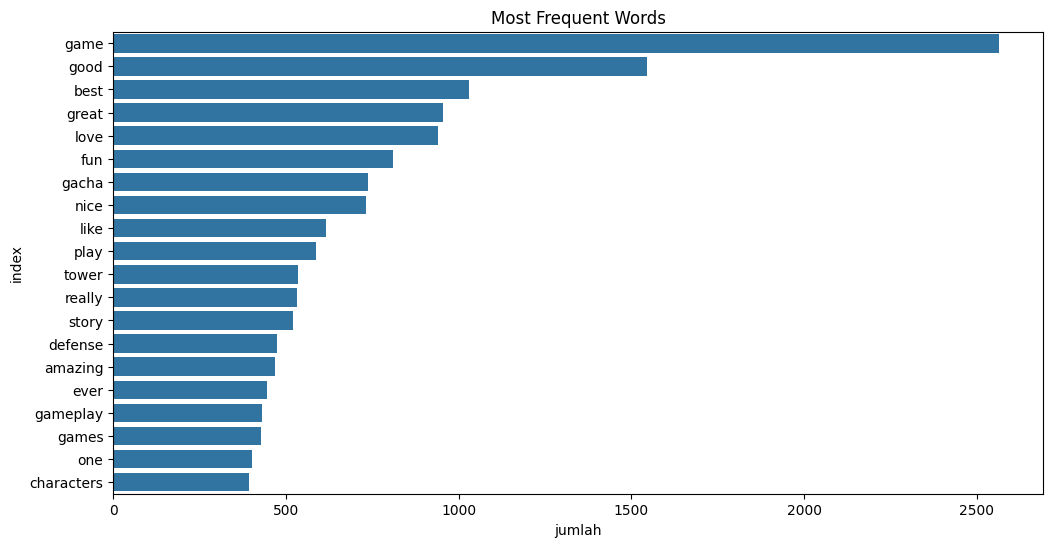

In [233]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

# Data Splitting

In [234]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
0,4533db64-cb99-4501-89c0-3ed34ba30938,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"One of the few good mobile games in the 2020s, and one of the best tower defenses out there- and still has constant updates. Been playing for about 2 1/2 years with only one complaint: Auto-redeploy not always being consistent. However, I can look past it with how many characters, modes, mechanics and lore/story the game has. It'll take years to run out of things to do. Warning though, early-game you will miss out on a lot of things due to not being strong enough or having enough resources saved",5,566,28.4.01,2025-06-02 19:39:43,None,NaT,28.4.01,One of the few good mobile games in the s and one of the best tower defenses out there and still has constant updates Been playing for about years with only one complaint Autoredeploy not always being consistent However I can look past it with how many characters modes mechanics and lorestory the game has Itll take years to run out of things to do Warning though earlygame you will miss out on a lot of things due to not being strong enough or having enough resources saved,one of the few good mobile games in the s and one of the best tower defenses out there and still has constant updates been playing for about years with only one complaint autoredeploy not always being consistent however i can look past it with how many characters modes mechanics and lorestory the game has itll take years to run out of things to do warning though earlygame you will miss out on a lot of things due to not being strong enough or having enough resources saved,"[one, of, the, few, good, mobile, games, in, the, s, and, one, of, the, best, tower, defenses, out, there, and, still, has, constant, updates, been, playing, for, about, years, with, only, one, complaint, autoredeploy, not, always, being, consistent, however, i, can, look, past, it, with, how, many, characters, modes, mechanics, and, lorestory, the, game, has, itll, take, years, to, run, out, of, things, to, do, warning, though, earlygame, you, will, miss, out, on, a, lot, of, things, due, to, not, being, strong, enough, or, having, enough, resources, saved]","[one, good, mobile, games, one, best, tower, defenses, still, constant, updates, playing, years, one, complaint, autoredeploy, always, consistent, however, look, past, many, characters, modes, mechanics, lorestory, game, itll, take, years, run, things, warning, though, earlygame, miss, lot, things, due, strong, enough, enough, resources, saved]",one good mobile games one best tower defenses still constant updates playing years one complaint autoredeploy always consistent however look past many characters modes mechanics lorestory game itll take years run things warning though earlygame miss lot things due strong enough enough resources saved,0.8885,positive,44
1,ccb34593-f129-415a-bc92-f6b0bb6674d0,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"I've been playing this game for 5 years, and I can easily say it's one of my all time favorites. Few games, or even films, tackle the subjects and themes Arknights does with this level of thoughtfulness and maturity. Every event is compelling, the cast is varied and complex, and the story and worldbuilding stand a cut above any of its contemporaries. It deserves all the support and recognition it can get. If you like political Sci Fi/fantasy and visual novels, I can't recommend it enough.",5,137,32.6.21,2026-02-10 01:19:56,None,NaT,32.6.21,Ive been playing this game for years and I can easily say its one of my all time favorites Few games or even films tackle the subjects

In [235]:
X = clean_df['text_akhir']
y = clean_df['polarity']

In [236]:
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [237]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

,account,actually,add,ads,almost,already,also,always,amazing,anime,...,wish,without,wont,work,worth,would,year,years,yostar,youre
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.191203,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.377482,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.274225,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.257973,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.161282,0.000000,0.317943,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.403717,0.0,0.0,0.0,0.173279,0.215186,0.200831,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31307,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
31308,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
31309,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
31310,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0


# Permodelan

In [238]:
# Lakukan one hot encoding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(clean_df['text_akhir'])

X_tokenized = tokenizer.texts_to_sequences(clean_df['text_akhir'])

max_sequence_length = int(np.percentile([len(x) for x in X_tokenized], 95))
X_padded = pad_sequences(X_tokenized, maxlen=max_sequence_length, padding='post')

# Label encoder untuk 'polarity' labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(clean_df['polarity'])

# One hot encoding
y_one_hot = to_categorical(y_encoded)

In [239]:
from tensorflow.keras.callbacks import EarlyStopping

class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

## RNN

In [240]:
# Pisah data train dan dataset
from sklearn.model_selection import train_test_split
# 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_one_hot, test_size=0.3, random_state=42
)

In [241]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, SimpleRNN, Dense, Bidirectional, Dropout
from sklearn.utils.class_weight import compute_class_weight

vocabulary_size = len(tokenizer.word_index) + 1
embedding_dim = 128
num_classes = y_one_hot.shape[1]


# Build the SimpleRNN model
rnn_model = Sequential([
    Embedding(input_dim=vocabulary_size, output_dim=embedding_dim),
    SpatialDropout1D(0.2),
    Bidirectional(SimpleRNN(256, dropout=0.2)),
    Dense(num_classes, activation='softmax'),
])

# Compile the model
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
rnn_model.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_30            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_25                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [242]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1,
)

print("RNN Model training complete.")

Epoch 1/15
685/685 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7837 - loss: 0.5796 - val_accuracy: 0.8755 - val_loss: 0.3485
Epoch 2/15
685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8921 - loss: 0.3060 - val_accuracy: 0.8984 - val_loss: 0.3174
Epoch 3/15
685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9263 - loss: 0.2279 - val_accuracy: 0.9105 - val_loss: 0.2742
Epoch 4/15
685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9471 - loss: 0.1703 - val_accuracy: 0.9067 - val_loss: 0.3113
Epoch 5/15
685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9490 - loss: 0.1689 - val_accuracy: 0.9070 - val_loss: 0.2959
Epoch 6/15
685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9515 - loss: 0.1558 - val_accuracy: 0.8937 - val_loss: 0.3218
RNN Model training complete.


In [243]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

loss_train_rnn, acc_train_rnn = rnn_model.evaluate(X_train, y_train, verbose=0)
loss_test_rnn,  acc_test_rnn  = rnn_model.evaluate(X_test,  y_test,  verbose=0)

print('RNN + Embedding + 80/20')
print(f'Accuracy Train : {acc_train_rnn:.4f} ({acc_train_rnn*100:.2f}%)')
print(f'Accuracy Test  : {acc_test_rnn:.4f} ({acc_test_rnn*100:.2f}%)')

y_pred_s1 = rnn_model.predict(X_test)
y_pred_s1_classes = np.argmax(y_pred_s1, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_s1_classes, target_names=label_encoder.classes_))

RNN + Embedding + 80/20
Accuracy Train : 0.9584 (95.84%)
Accuracy Test  : 0.9105 (91.05%)
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.65      0.62      0.64       964
     neutral       0.88      0.90      0.89      1429
    positive       0.95      0.95      0.95      7001

    accuracy                           0.91      9394
   macro avg       0.83      0.82      0.83      9394
weighted avg       0.91      0.91      0.91      9394



## GRU

In [244]:
# 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_one_hot, test_size=0.2, random_state=42
)

In [245]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, GRU, Dense, Bidirectional, Dropout
from sklearn.utils.class_weight import compute_class_weight

vocabulary_size = len(tokenizer.word_index) + 1
embedding_dim = 128
num_classes = y_one_hot.shape[1]


# Build the SimpleRNN model
gru_model = Sequential([
    Embedding(input_dim=vocabulary_size, output_dim=embedding_dim),
    SpatialDropout1D(0.2),
    Bidirectional(GRU(256, dropout=0.2)),
    Dense(num_classes, activation='softmax'),
])

# Compile the model
gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
gru_model.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_31 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_31            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_26                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [246]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1,
    class_weight=class_weight_dict
)

print("GRU Model training complete.")

Epoch 1/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.7114 - loss: 0.6523 - val_accuracy: 0.9029 - val_loss: 0.2704
Epoch 2/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9192 - loss: 0.2362 - val_accuracy: 0.9147 - val_loss: 0.2557
Epoch 3/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9488 - loss: 0.1583 - val_accuracy: 0.9101 - val_loss: 0.2731
Epoch 4/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9616 - loss: 0.1177 - val_accuracy: 0.9170 - val_loss: 0.2587
Epoch 5/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9692 - loss: 0.0990 - val_accuracy: 0.9234 - val_loss: 0.2708
GRU Model training complete.


In [247]:
# Evaluasi GRU
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

loss_train_gru, acc_train_gru = gru_model.evaluate(X_train, y_train, verbose=0)
loss_test_gru,  acc_test_gru  = gru_model.evaluate(X_test,  y_test,  verbose=0)

print('GRU')
print(f'Accuracy Train : {acc_train_gru:.4f} ({acc_train_gru*100:.2f}%)')
print(f'Accuracy Test  : {acc_test_gru:.4f} ({acc_test_gru*100:.2f}%)')

y_pred_s1 = gru_model.predict(X_test)
y_pred_s1_classes = np.argmax(y_pred_s1, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_s1_classes, target_names=label_encoder.classes_))

GRU
Accuracy Train : 0.9392 (93.92%)
Accuracy Test  : 0.9147 (91.47%)
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.60      0.85      0.70       640
     neutral       0.91      0.93      0.92       962
    positive       0.98      0.92      0.95      4661

    accuracy                           0.91      6263
   macro avg       0.83      0.90      0.86      6263
weighted avg       0.93      0.91      0.92      6263



## LSTM

In [248]:
# 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_one_hot, test_size=0.2, random_state=42
)

In [249]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense, Bidirectional, Dropout

vocabulary_size = len(tokenizer.word_index) + 1
embedding_dim = 128
num_classes = y_one_hot.shape[1]

# Build the LSTM model
lstm_model = Sequential([
    Embedding(input_dim=vocabulary_size, output_dim=embedding_dim),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(256, dropout=0.2)),
    Dense(num_classes, activation='softmax'),
])

# Compile the model
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
lstm_model.summary()


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_32 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_32            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_27                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [250]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1,
)

print("LSTM Model training complete.")

Epoch 1/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.8302 - loss: 0.4684 - val_accuracy: 0.9262 - val_loss: 0.2147
Epoch 2/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9457 - loss: 0.1636 - val_accuracy: 0.9358 - val_loss: 0.1871
Epoch 3/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9651 - loss: 0.1062 - val_accuracy: 0.9355 - val_loss: 0.2174
Epoch 4/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9781 - loss: 0.0722 - val_accuracy: 0.9326 - val_loss: 0.2242
Epoch 5/15
783/783 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9807 - loss: 0.0569 - val_accuracy: 0.9363 - val_loss: 0.2486
LSTM Model training complete.


In [251]:
# Evaluasi LSTM
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

loss_train_lstm, acc_train_lstm = lstm_model.evaluate(X_train, y_train, verbose=0)
loss_test_lstm,  acc_test_lstm  = lstm_model.evaluate(X_test,  y_test,  verbose=0)

print('LSTM')
print(f'Accuracy Train : {acc_train_lstm:.4f} ({acc_train_lstm*100:.2f}%)')
print(f'Accuracy Test  : {acc_test_lstm:.4f} ({acc_test_lstm*100:.2f}%)')

y_pred_s1 = lstm_model.predict(X_test)
y_pred_s1_classes = np.argmax(y_pred_s1, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_s1_classes, target_names=label_encoder.classes_))

LSTM
Accuracy Train : 0.9719 (97.19%)
Accuracy Test  : 0.9358 (93.58%)
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.72      0.74       640
     neutral       0.95      0.89      0.92       962
    positive       0.95      0.98      0.96      4661

    accuracy                           0.94      6263
   macro avg       0.89      0.86      0.88      6263
weighted avg       0.93      0.94      0.93      6263



In [252]:
import pandas as pd

# Membuat DataFrame untuk hasil akurasi
results_df = pd.DataFrame({
    'Model': ['RNN', 'GRU', 'LSTM'],
    'Accuracy Train': [acc_train_rnn, acc_train_gru, acc_train_lstm],
    'Accuracy Test': [acc_test_rnn, acc_test_gru, acc_test_lstm]
})
# Menampilkan hanya kolom "Accuracy Test"
accuracy_test_only = results_df[['Model', 'Accuracy Test']]
print(accuracy_test_only)

  Model  Accuracy Test
0   RNN       0.910475
1   GRU       0.914737
2  LSTM       0.935813


In [253]:
# Mengurutkan DataFrame berdasarkan kolom "Accuracy Test" dari tertinggi ke terendah
accuracy_test_sorted = accuracy_test_only.sort_values(by='Accuracy Test', ascending=False)

# Menampilkan DataFrame yang telah diurutkan
print(accuracy_test_sorted)


  Model  Accuracy Test
2  LSTM       0.935813
1   GRU       0.914737
0   RNN       0.910475


In [254]:
sample_sentences = [
    "Arknights is an amazing game with great storyline and wonderful operators",
    "The new operator in Arknights is so weak and disappointing, total waste of pulls",
    "The latest Arknights update is decent"
]

print("Inference Sentimen")

for kalimat in sample_sentences:
    kalimat_cleaned     = cleaningText(kalimat)
    kalimat_casefolded  = casefoldingText(kalimat_cleaned)
    kalimat_tokenized   = tokenizingText(kalimat_casefolded)
    kalimat_filtered    = filteringText(kalimat_tokenized)
    kalimat_final       = toSentence(kalimat_filtered)

    # Tokenize dan pad
    seq     = tokenizer.texts_to_sequences([kalimat_final])
    padded  = pad_sequences(seq, maxlen=max_sequence_length, padding='post')

    # Prediksi
    prediksi_prob        = lstm_model.predict(padded, verbose=0)
    predicted_class_idx  = np.argmax(prediksi_prob, axis=1)
    predicted_sentiment  = label_encoder.inverse_transform(predicted_class_idx)[0]

    # Probabilitas per kelas
    classes = label_encoder.classes_
    probs   = prediksi_prob[0]

    print(f"\nKalimat  : {kalimat}")
    print(f"Hasil    : {predicted_sentiment.upper()}")
    print(f"Probabilitas:")
    for cls, prob in zip(classes, probs):
        print(f"  {cls:<10}: {prob:.4f} ({prob*100:.2f}%)")
    print("-" * 60)

Inference Sentimen

Kalimat  : Arknights is an amazing game with great storyline and wonderful operators
Hasil    : POSITIVE
Probabilitas:
  negative  : 0.0001 (0.01%)
  neutral   : 0.0001 (0.01%)
  positive  : 0.9998 (99.98%)
------------------------------------------------------------

Kalimat  : The new operator in Arknights is so weak and disappointing, total waste of pulls
Hasil    : NEGATIVE
Probabilitas:
  negative  : 0.9467 (94.67%)
  neutral   : 0.0192 (1.92%)
  positive  : 0.0342 (3.42%)
------------------------------------------------------------

Kalimat  : The latest Arknights update is decent
Hasil    : NEUTRAL
Probabilitas:
  negative  : 0.0048 (0.48%)
  neutral   : 0.9512 (95.12%)
  positive  : 0.0439 (4.39%)
------------------------------------------------------------


# Inference

In [256]:
kalimat_baru = input("Masukkan kalimat baru: ")

# Melakukan preprocessing pada kalimat baru
kalimat_baru_cleaned = cleaningText(kalimat_baru)
kalimat_baru_casefolded = casefoldingText(kalimat_baru_cleaned)
kalimat_baru_tokenized = tokenizingText(kalimat_baru_casefolded)
kalimat_baru_filtered = filteringText(kalimat_baru_tokenized)
kalimat_baru_final = toSentence(kalimat_baru_filtered)

# Menggunakan objek tfidf yang sudah di-fit dari pelatihan sebelumnya
X_kalimat_baru = tfidf.transform([kalimat_baru_final])

# Memperoleh prediksi sentimen kalimat baru
prediksi_prob = lstm_model.predict(X_kalimat_baru)

# Mendapatkan indeks kelas dengan probabilitas tertinggi
predicted_class_index = np.argmax(prediksi_prob, axis=1)

# Mengubah indeks kelas menjadi label sentimen menggunakan label_encoder
predicted_sentiment = label_encoder.inverse_transform(predicted_class_index)[0]

# Menampilkan hasil prediksi
print(f"Sentimen kalimat baru adalah: {predicted_sentiment.upper()}.")


Masukkan kalimat baru: is decent gacha game
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Sentimen kalimat baru adalah: NEUTRAL.
